# Dog clustering #

Welcome to this assignment. In this asignment you will see if dogs can be clustered in (sub) species.<br>
In the end of the Notebook the assignments are given.

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/generated_dogs.csv'
'''
The dataset consists of 10000 dogs who died of old age. It is generated using meta data from dogs.

'''
df = pd.read_csv(url)
df.head()

,Breed,Gender,Age_time_of_death,Height,Weight,Likes,Skills
0,Border Collie,Male,13.3,20.70,40.50,likes_people_better_than_dogs,high_trainability
1,Basset Hound,Male,12.7,13.65,51.02,likes_dogs_better_than_people,no_special_skills
2,Dachshund,Female,14.0,8.59,24.58,likes_dogs_better_than_people,barks_like_hell
3,Boston Terrier,Male,12.3,16.27,20.13,likes_people_better_than_dogs,no_special_skills
4,Chihuahua,Male,15.3,7.14,5.92,likes_dogs_better_than_people,barks_like_hell


# First step #


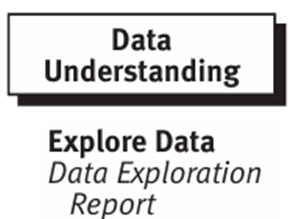


I will help you a little bit. We could try a pairplot.

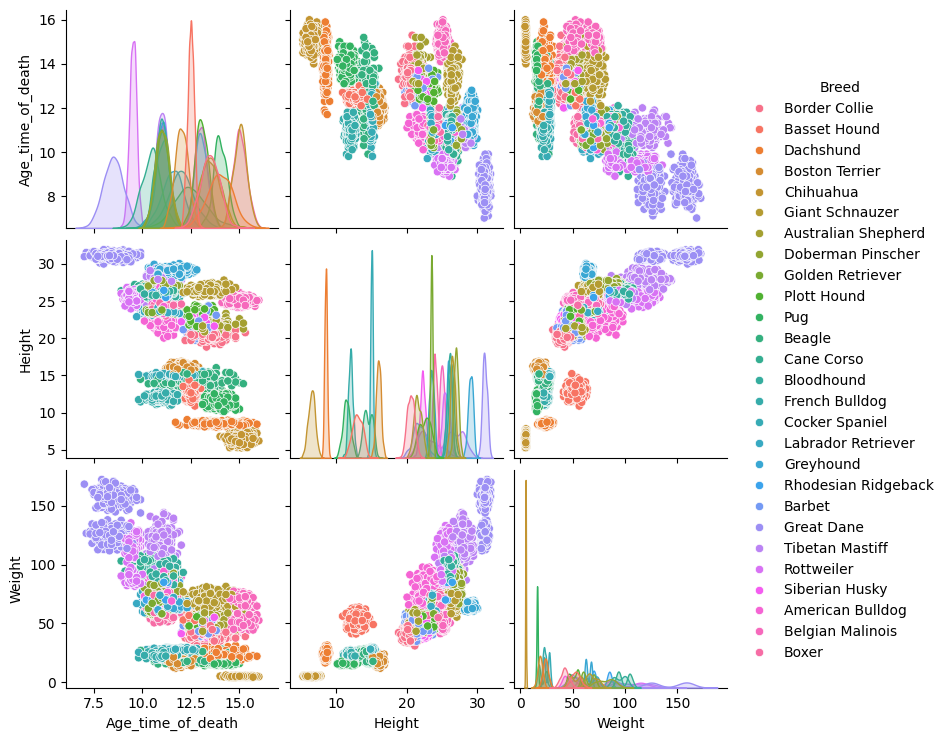

In [2]:
import seaborn as sns

sns.pairplot(df.drop(['Gender','Skills','Likes'],axis=1), hue='Breed')

1) Can you apply different cluster algoritms to the Height/Weight/Age_time_of_death of the dogs?<br>
2) Can you trace back which dogs fall in the same cluster? Do you think it is logical?



🛠️ Preparing data for clustering...
📉 Calculating Elbow Curve...


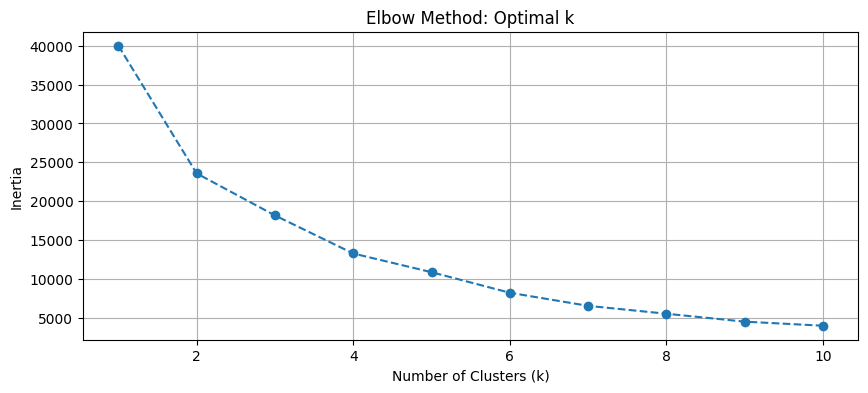

🚀 Running K-Means with k=3...
✅ Similarity with Real Breeds (ARI Score): 0.0744


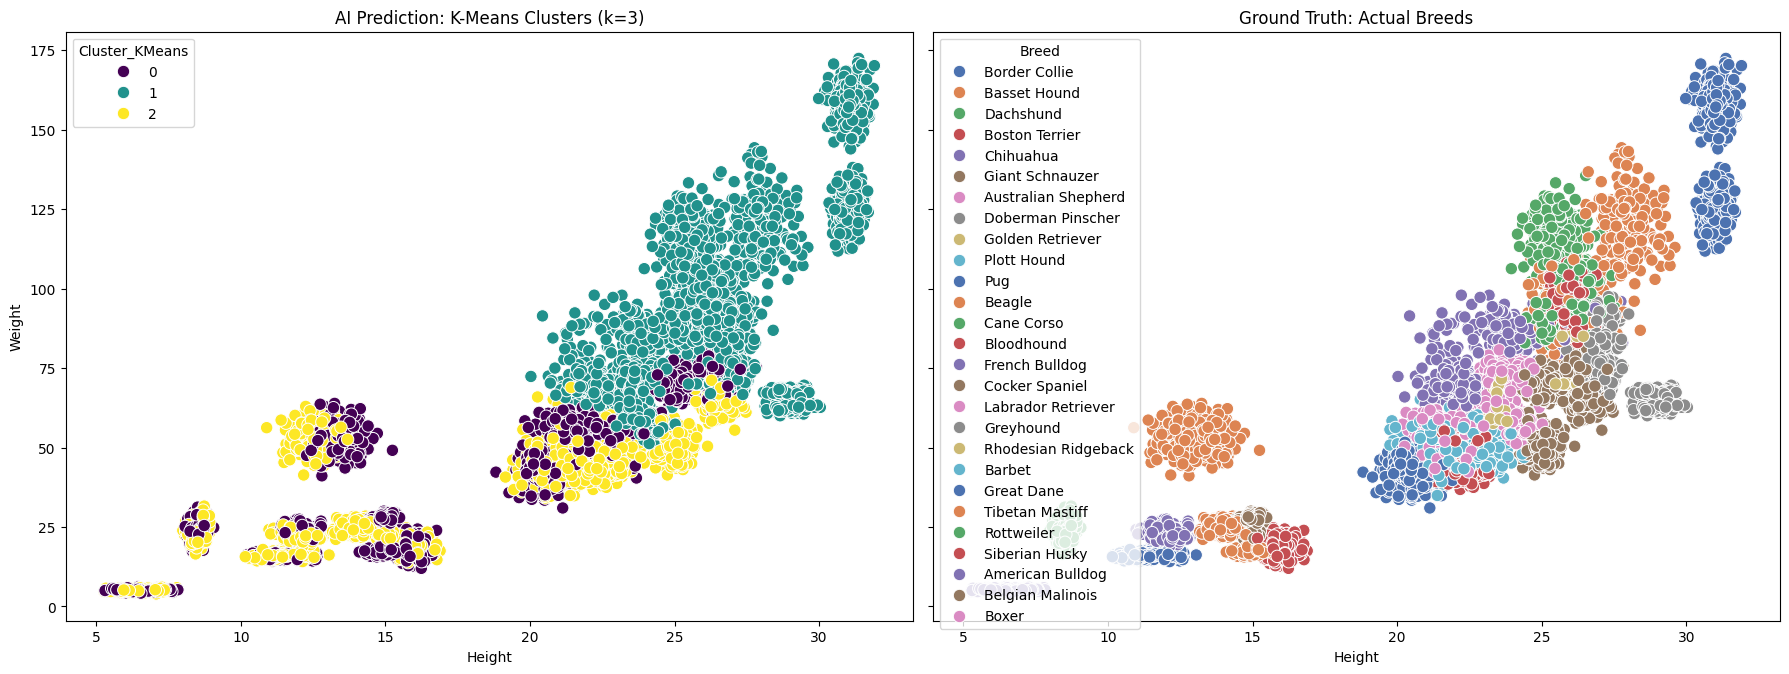

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import adjusted_rand_score

# --- 1. Data Preprocessing ---
print("🛠️ Preparing data for clustering...")
df_clus = df.copy()

# Encode Gender for clustering
le = LabelEncoder()
if 'Gender' in df_clus.columns:
    df_clus['Gender_Enc'] = le.fit_transform(df_clus['Gender'].astype(str))

# Select features (Numerical only)
# Note: We do NOT use 'Breed' for training, only for comparison later!
features = ['Age_time_of_death', 'Height', 'Weight', 'Gender_Enc']
X = df_clus[features].dropna()

# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# --- 2. Elbow Method ---
print("📉 Calculating Elbow Curve...")
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method: Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# --- 3. Apply K-Means ---
# Set k to the number of breeds you expect (or based on elbow)
optimal_k = 3 
print(f"🚀 Running K-Means with k={optimal_k}...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clus['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# --- 4. Comparison with Ground Truth (Breed) ---
# Calculate Adjusted Rand Index (1.0 is perfect match, 0.0 is random)
ari_score = adjusted_rand_score(df_clus['Breed'], df_clus['Cluster_KMeans'])
print(f"✅ Similarity with Real Breeds (ARI Score): {ari_score:.4f}")

# Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot 1: The AI Clusters
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Cluster_KMeans', palette='viridis', s=80, ax=axes[0])
axes[0].set_title(f'AI Prediction: K-Means Clusters (k={optimal_k})')

# Plot 2: The Real Breeds
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Breed', palette='deep', s=80, ax=axes[1])
axes[1].set_title('Ground Truth: Actual Breeds')

plt.tight_layout()
plt.show()

🌳 Plotting Dendrogram...


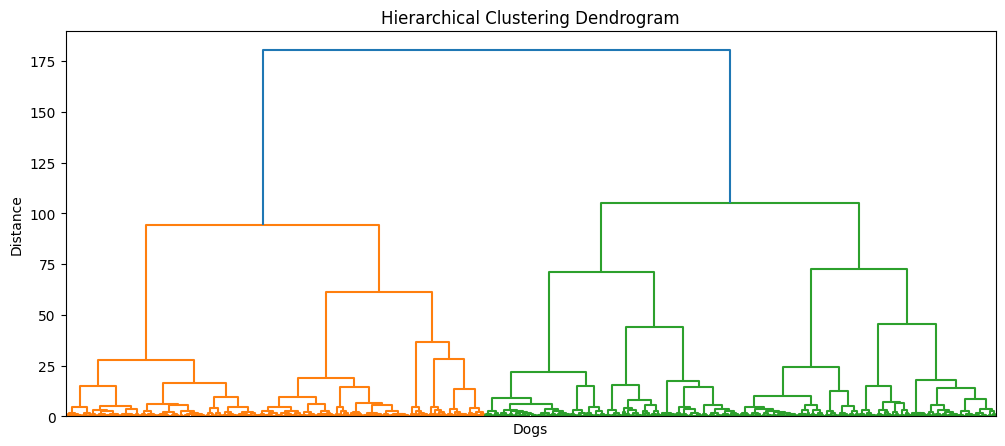

🚀 Running Agglomerative Clustering (n=3)...
✅ Similarity with Real Breeds (ARI Score): 0.0759


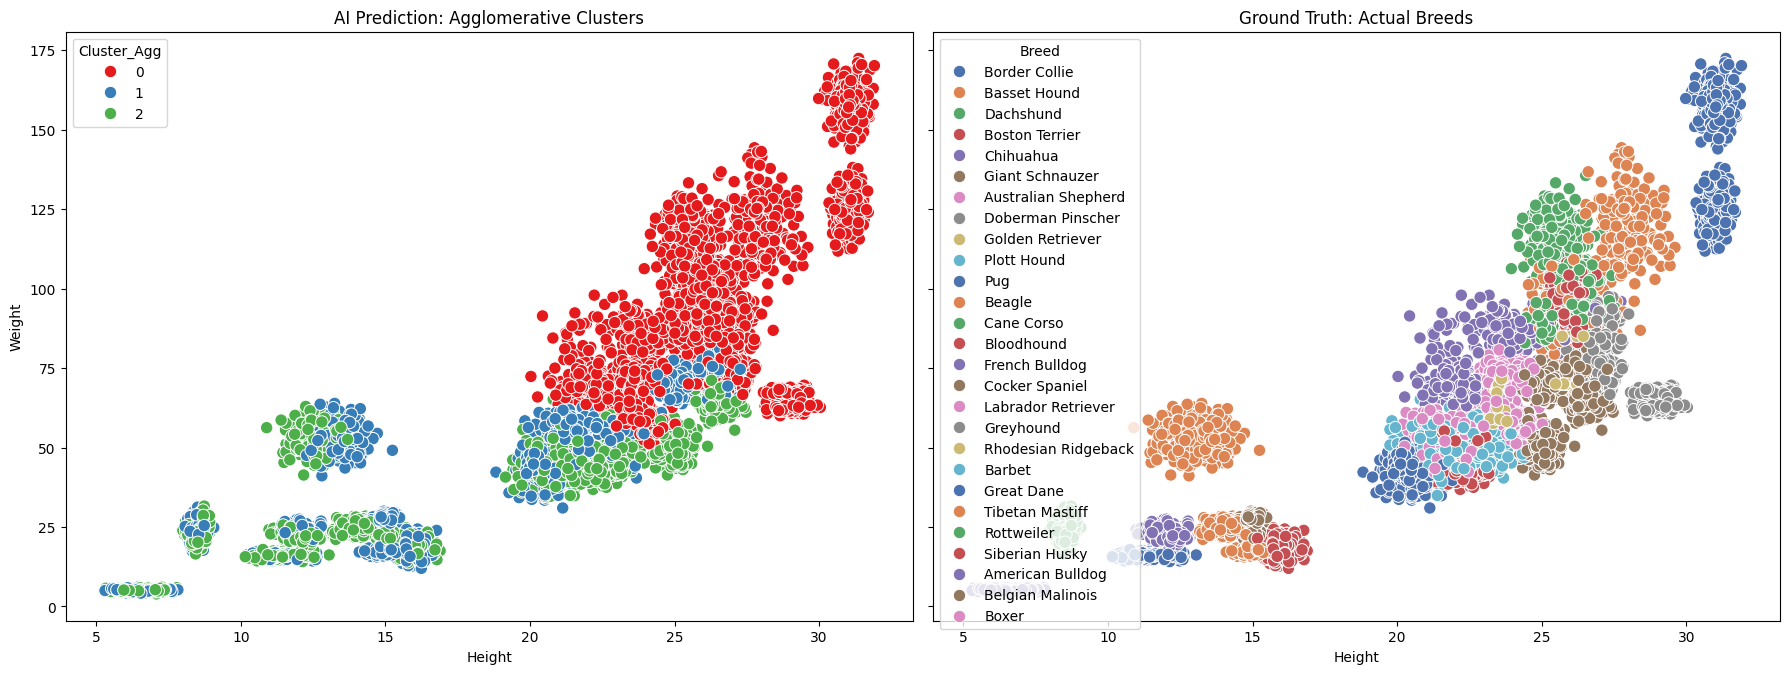

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score

# (Assuming X_scaled is already created in the previous cell)

# --- 1. Dendrogram ---
print("🌳 Plotting Dendrogram...")
plt.figure(figsize=(12, 5))
dendro_linkage = linkage(X_scaled, method='ward')
dendrogram(dendro_linkage, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Dogs')
plt.ylabel('Distance')
plt.show()

# --- 2. Apply Agglomerative Clustering ---
n_clusters = 3 
print(f"🚀 Running Agglomerative Clustering (n={n_clusters})...")

agg_clus = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df_clus['Cluster_Agg'] = agg_clus.fit_predict(X_scaled)

# --- 3. Comparison with Ground Truth ---
ari_score = adjusted_rand_score(df_clus['Breed'], df_clus['Cluster_Agg'])
print(f"✅ Similarity with Real Breeds (ARI Score): {ari_score:.4f}")

# Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot 1: AI Clusters
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Cluster_Agg', palette='Set1', s=80, ax=axes[0])
axes[0].set_title(f'AI Prediction: Agglomerative Clusters')

# Plot 2: Real Breeds
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Breed', palette='deep', s=80, ax=axes[1])
axes[1].set_title('Ground Truth: Actual Breeds')

plt.tight_layout()
plt.show()

📏 Calculating K-Distance Graph...


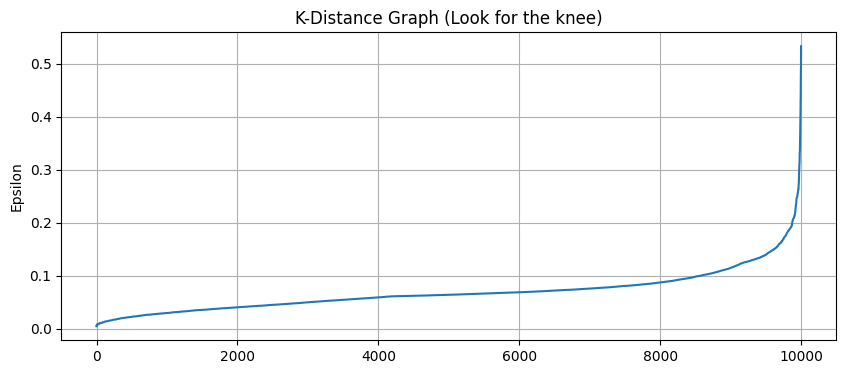

🚀 Running DBSCAN (eps=0.5)...
   -> Found 6 clusters (excluding noise).
✅ Similarity with Real Breeds (ARI Score): 0.0607


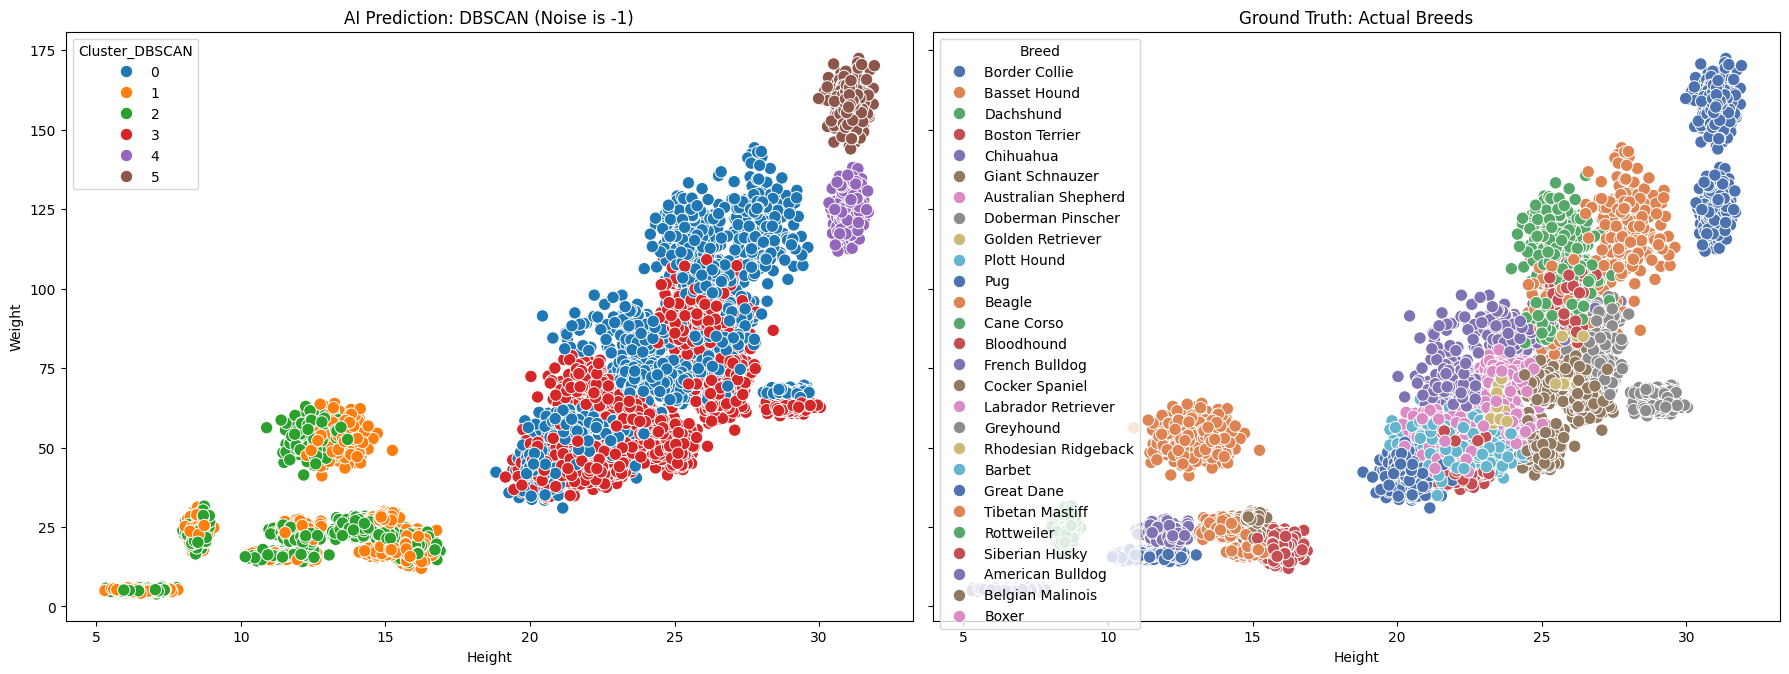

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

# --- 1. K-Distance Graph ---
print("📏 Calculating K-Distance Graph...")
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.title('K-Distance Graph (Look for the knee)')
plt.ylabel('Epsilon')
plt.grid(True)
plt.show()

# --- 2. Apply DBSCAN ---
eps_value = 0.5 # Adjust based on plot!
print(f"🚀 Running DBSCAN (eps={eps_value})...")

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
df_clus['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Check stats
n_clusters_db = len(set(df_clus['Cluster_DBSCAN'])) - (1 if -1 in df_clus['Cluster_DBSCAN'].values else 0)
print(f"   -> Found {n_clusters_db} clusters (excluding noise).")

# --- 3. Comparison with Ground Truth ---
ari_score = adjusted_rand_score(df_clus['Breed'], df_clus['Cluster_DBSCAN'])
print(f"✅ Similarity with Real Breeds (ARI Score): {ari_score:.4f}")

# Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot 1: AI Clusters (Note: -1 is Noise)
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Cluster_DBSCAN', palette='tab10', s=80, ax=axes[0])
axes[0].set_title(f'AI Prediction: DBSCAN (Noise is -1)')

# Plot 2: Real Breeds
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Breed', palette='deep', s=80, ax=axes[1])
axes[1].set_title('Ground Truth: Actual Breeds')

plt.tight_layout()
plt.show()

📉 Calculating BIC Scores...


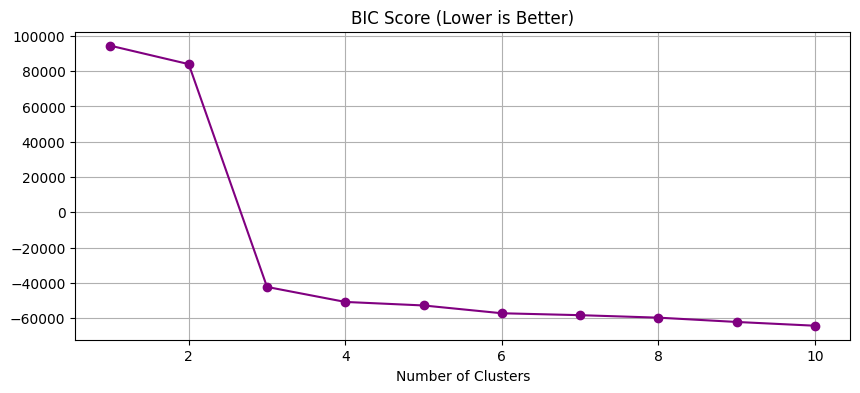

🚀 Running GMM (n=3)...
✅ Similarity with Real Breeds (ARI Score): 0.0030


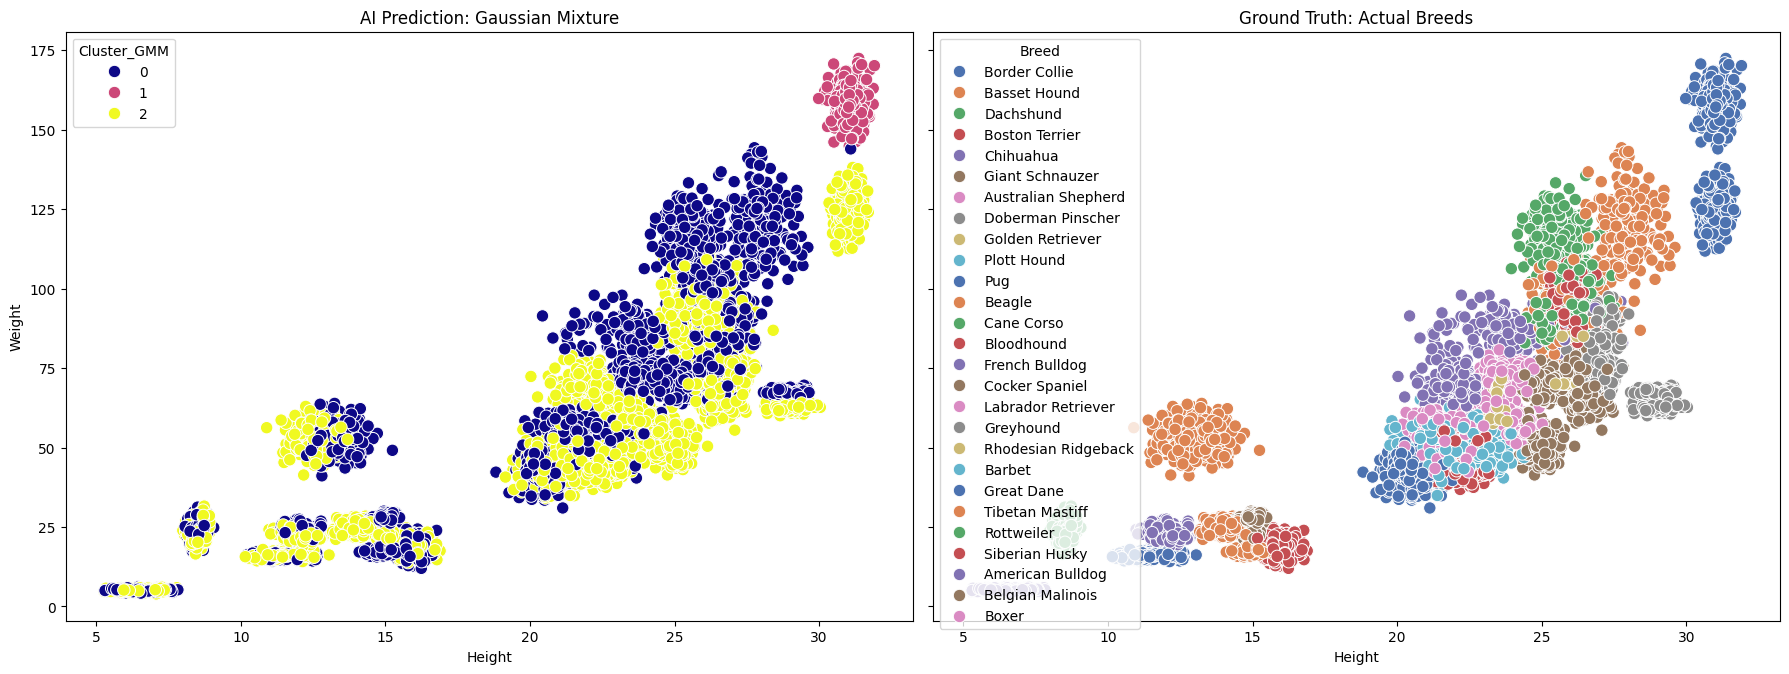

In [6]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# --- 1. BIC Score Plot ---
print("📉 Calculating BIC Scores...")
n_components_range = range(1, 11)
bic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.figure(figsize=(10, 4))
plt.plot(n_components_range, bic_scores, marker='o', color='purple')
plt.title('BIC Score (Lower is Better)')
plt.xlabel('Number of Clusters')
plt.grid(True)
plt.show()

# --- 2. Apply GMM ---
optimal_n = 3 
print(f"🚀 Running GMM (n={optimal_n})...")

gmm = GaussianMixture(n_components=optimal_n, random_state=42)
df_clus['Cluster_GMM'] = gmm.fit_predict(X_scaled)

# --- 3. Comparison with Ground Truth ---
ari_score = adjusted_rand_score(df_clus['Breed'], df_clus['Cluster_GMM'])
print(f"✅ Similarity with Real Breeds (ARI Score): {ari_score:.4f}")

# Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot 1: AI Clusters
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Cluster_GMM', palette='plasma', s=80, ax=axes[0])
axes[0].set_title(f'AI Prediction: Gaussian Mixture')

# Plot 2: Real Breeds
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Breed', palette='deep', s=80, ax=axes[1])
axes[1].set_title('Ground Truth: Actual Breeds')

plt.tight_layout()
plt.show()

🚀 Running Spectral Clustering (n=3)...


/home/robin/.venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


✅ Similarity with Real Breeds (ARI Score): 0.0280


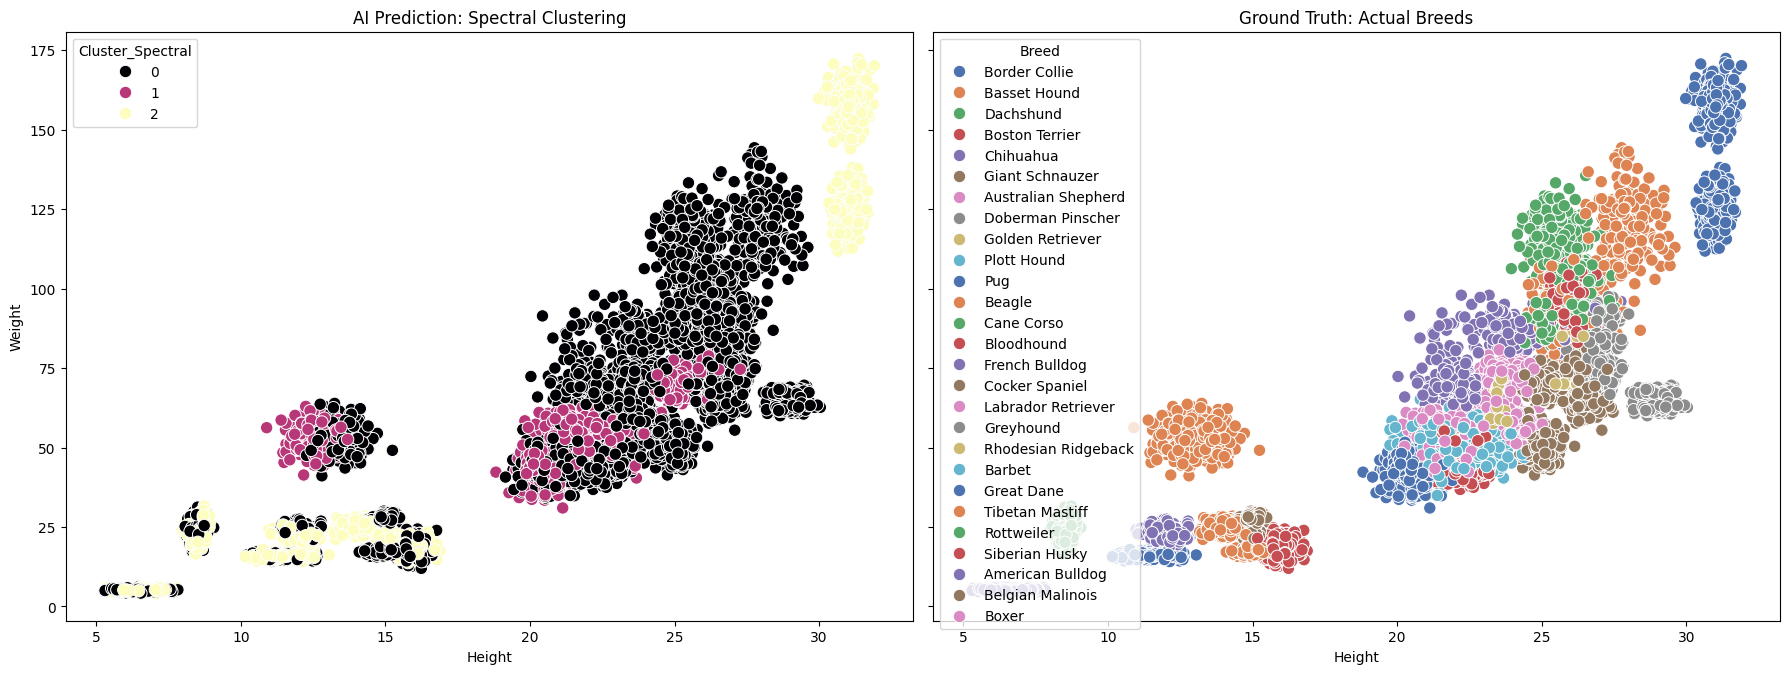

In [7]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

# --- 1. Apply Spectral Clustering ---
# Spectral needs to know the number of clusters beforehand
n_clusters_spectral = 3 
print(f"🚀 Running Spectral Clustering (n={n_clusters_spectral})...")

spectral = SpectralClustering(
    n_clusters=n_clusters_spectral, 
    affinity='nearest_neighbors', 
    random_state=42, 
    n_jobs=-1
)

df_clus['Cluster_Spectral'] = spectral.fit_predict(X_scaled)

# --- 2. Comparison with Ground Truth ---
ari_score = adjusted_rand_score(df_clus['Breed'], df_clus['Cluster_Spectral'])
print(f"✅ Similarity with Real Breeds (ARI Score): {ari_score:.4f}")

# Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot 1: AI Clusters
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Cluster_Spectral', palette='magma', s=80, ax=axes[0])
axes[0].set_title(f'AI Prediction: Spectral Clustering')

# Plot 2: Real Breeds
sns.scatterplot(data=df_clus, x='Height', y='Weight', hue='Breed', palette='deep', s=80, ax=axes[1])
axes[1].set_title('Ground Truth: Actual Breeds')

plt.tight_layout()
plt.show()